# California Housing — Modelos de Regresión

Análisis exploratorio, preprocesamiento, entrenamiento y evaluación de:
- **Regresión Lineal Múltiple**
- **Regresión Polinomial** (grados 2 y 3)

**Variable objetivo:** `median_house_value` (valor medio de la vivienda en USD).

## 1. Configuración del entorno

Se importan las librerías y los módulos del caso. Se agrega la raíz del proyecto al `sys.path` para poder importar `cases`.

In [1]:
import sys
from pathlib import Path

# Permite importar el paquete cases/ desde el notebook.
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from cases.california_housing.config import (
    RESULTS_DIR, RANDOM_STATE, TEST_SIZE, TARGET,
    NUMERIC_FEATURES, CATEGORICAL_FEATURES,
)
from cases.california_housing.preprocessing import load_data, build_preprocessor
from cases.california_housing.train import build_models
from cases.california_housing.evaluate import metrics_table

print('Entorno listo. Python', sys.version.split()[0])

Entorno listo. Python 3.14.6


## 2. Carga del dataset

Se carga el archivo `data/housing(1).csv` y se revisan dimensiones y primeras filas.

In [2]:
df = load_data()
print('Dimensiones (filas, columnas):', df.shape)
df.head()

Dimensiones (filas, columnas): (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Información general y tipos de datos

Revisamos los tipos de cada columna. Todas las numéricas son `float64` y solo `ocean_proximity` es texto.

In [3]:
df.info()
print()
print('Tipos de datos:')
print(df.dtypes.to_string())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB

Tipos de datos:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_ho

## 4. Valores nulos

Se cuentan los nulos por columna y su porcentaje. La única afectada es `total_bedrooms` con 207 valores (~1%), que se imputarán con la mediana.

In [4]:
nulos = df.isna().sum()
porcentaje = (df.isna().mean() * 100).round(3)
pd.DataFrame({'Nulos': nulos, 'Porcentaje %': porcentaje})

,Nulos,Porcentaje %
longitude,0,0.000
latitude,0,0.000
housing_median_age,0,0.000
total_rooms,0,0.000
total_bedrooms,207,1.003
population,0,0.000
households,0,0.000
median_income,0,0.000
median_house_value,0,0.000
ocean_proximity,0,0.000


## 5. Duplicados

Se verifica la existencia de filas duplicadas.

In [5]:
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 0


## 6. Estadísticas descriptivas

Se resumen las variables numéricas. Destacan `total_rooms` (máximo 39,320) y `median_house_value` con máximo de 500,001 (valor topado del dataset original, que se conserva).

In [6]:
df.select_dtypes(include='number').describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


## 7. Variable categórica: ocean_proximity

Hay 5 categorías; `ISLAND` solo tiene 5 observaciones (dato real que se conserva).

In [7]:
df['ocean_proximity'].value_counts().to_frame('Frecuencia')

,Frecuencia
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


## 8. Distribuciones

Histogramas de las variables numéricas y de la variable objetivo. `rooms`, `bedrooms`, `population` y `households` son asimétricas a la derecha; `median_house_value` muestra un pico en el tope de 500,001.

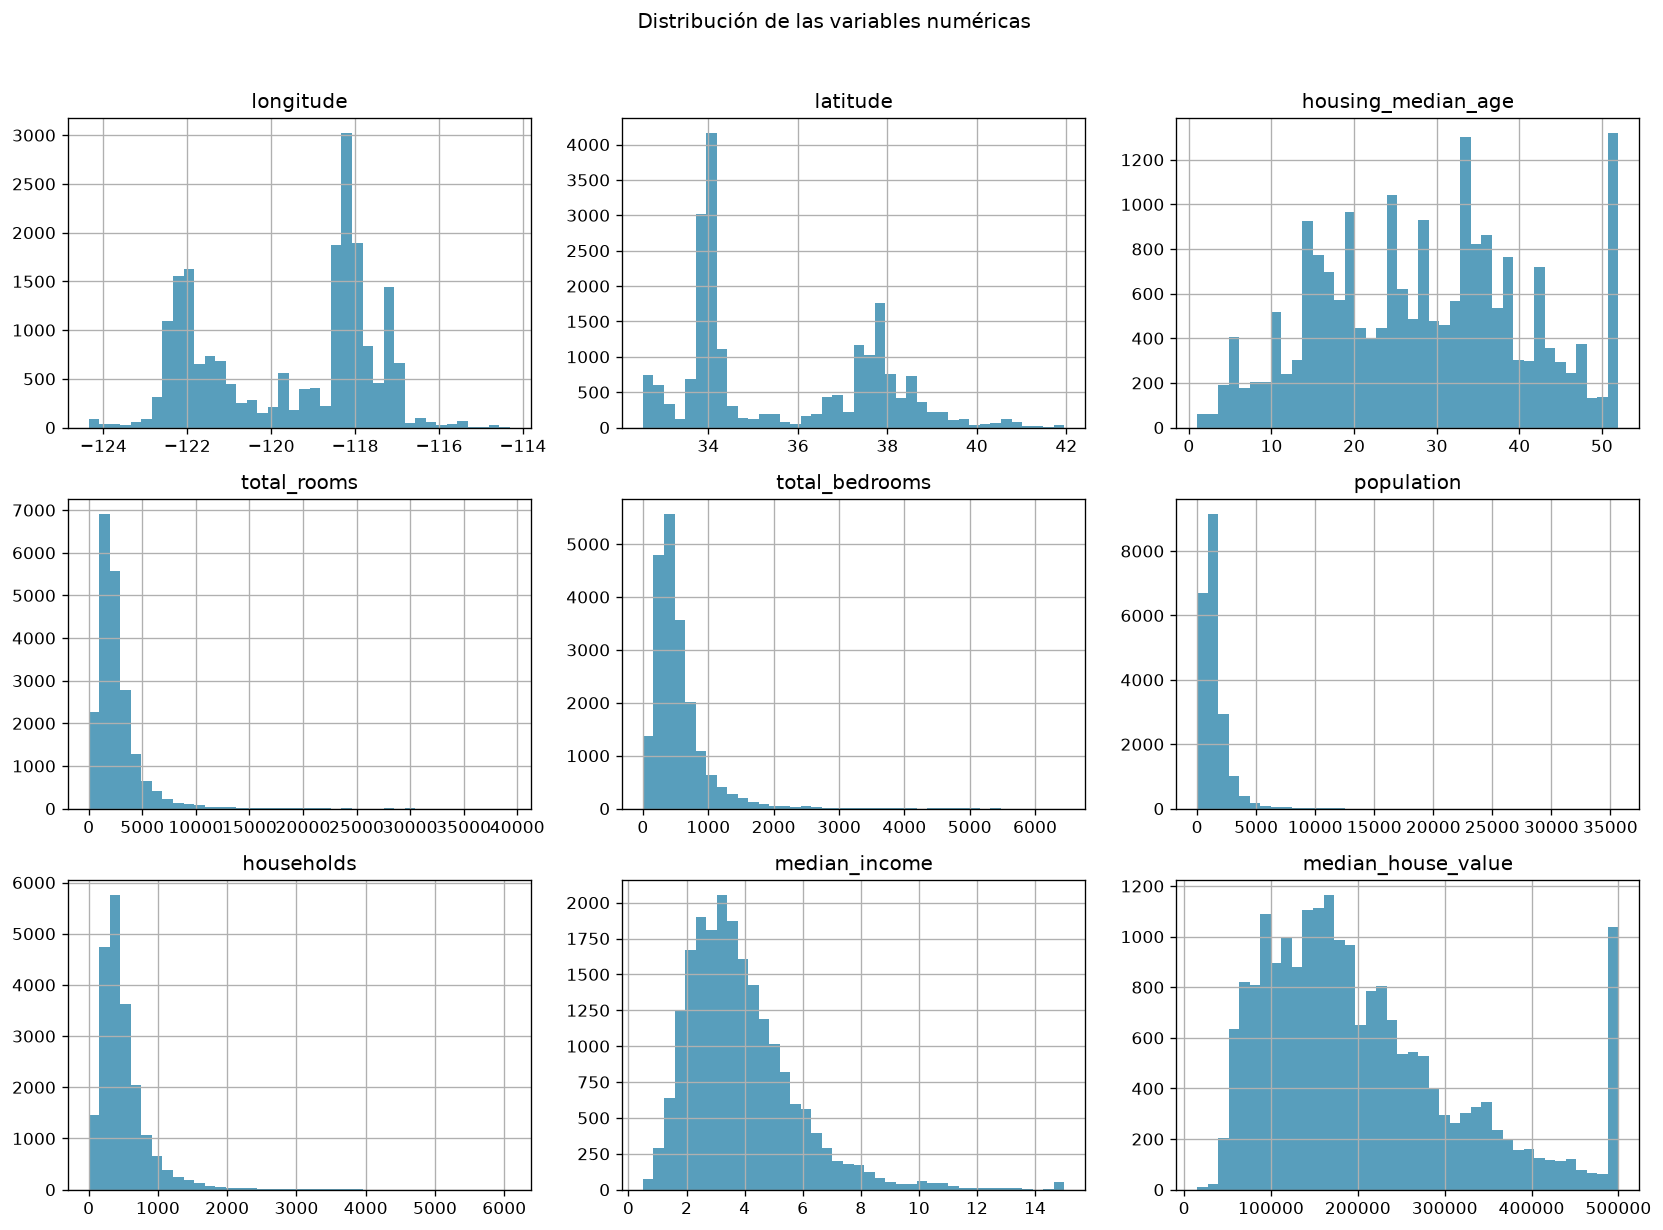

In [8]:
num_cols = NUMERIC_FEATURES + [TARGET]
df[num_cols].hist(bins=40, figsize=(14, 10), color='#2E86AB', alpha=0.8)
plt.suptitle('Distribución de las variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

## 9. Análisis de outliers

Se usan boxplots y la regla del IQR (Q1 − 1.5·IQR, Q3 + 1.5·IQR). Los conteos de rooms/bedrooms/population/households tienen ~6% de outliers, pero corresponden a distritos grandes reales (p. ej. Los Ángeles), por lo que **se conservan**. Los 965 valores de `median_house_value` en 500,001 son datos censurados del dataset y también se conservan.

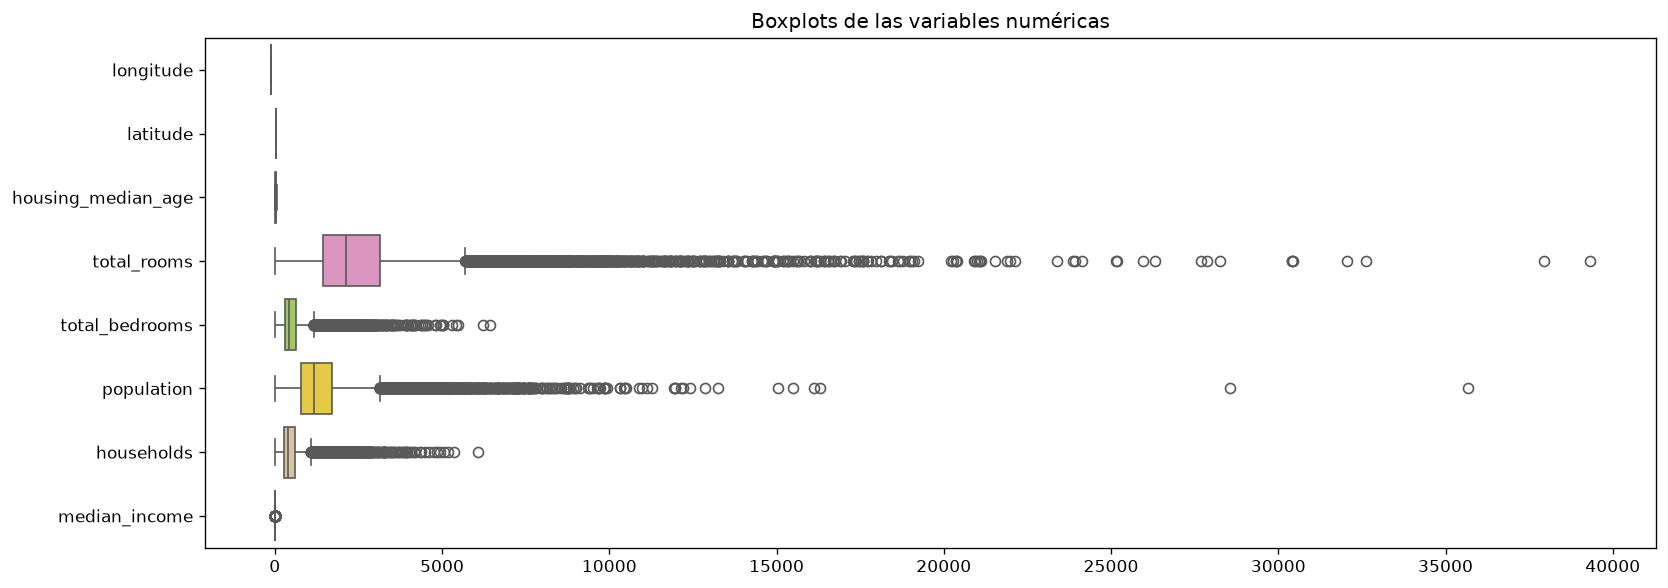

In [9]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df[NUMERIC_FEATURES], orient='h', palette='Set2')
plt.title('Boxplots de las variables numéricas')
plt.tight_layout()
plt.show()

In [10]:
print('Outliers por IQR:')
print(f"{'Variable':<20s} {'Outliers':>8s} {'%':>8s}")
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    print(f"{col:<20s} {int(mask.sum()):>8d} {100 * mask.mean():>7.2f}%")

# Verificación del tope de la variable objetivo
print('\nValores en el tope 500,001:', (df[TARGET] == 500001).sum(),
      f"({100 * (df[TARGET] == 500001).mean():.2f}%)")

Outliers por IQR:
Variable             Outliers        %
longitude                   0    0.00%
latitude                    0    0.00%
housing_median_age          0    0.00%
total_rooms              1287    6.24%
total_bedrooms           1271    6.16%
population               1196    5.79%
households               1220    5.91%
median_income             681    3.30%
median_house_value       1071    5.19%

Valores en el tope 500,001: 965 (4.68%)


## 10. Matriz de correlación

Se muestra la correlación de Pearson entre las variables numéricas. El predictor más correlacionado con la variable objetivo es `median_income` (0.688). Existen correlaciones muy altas entre `total_rooms`, `total_bedrooms`, `population` y `households` (>0.85).

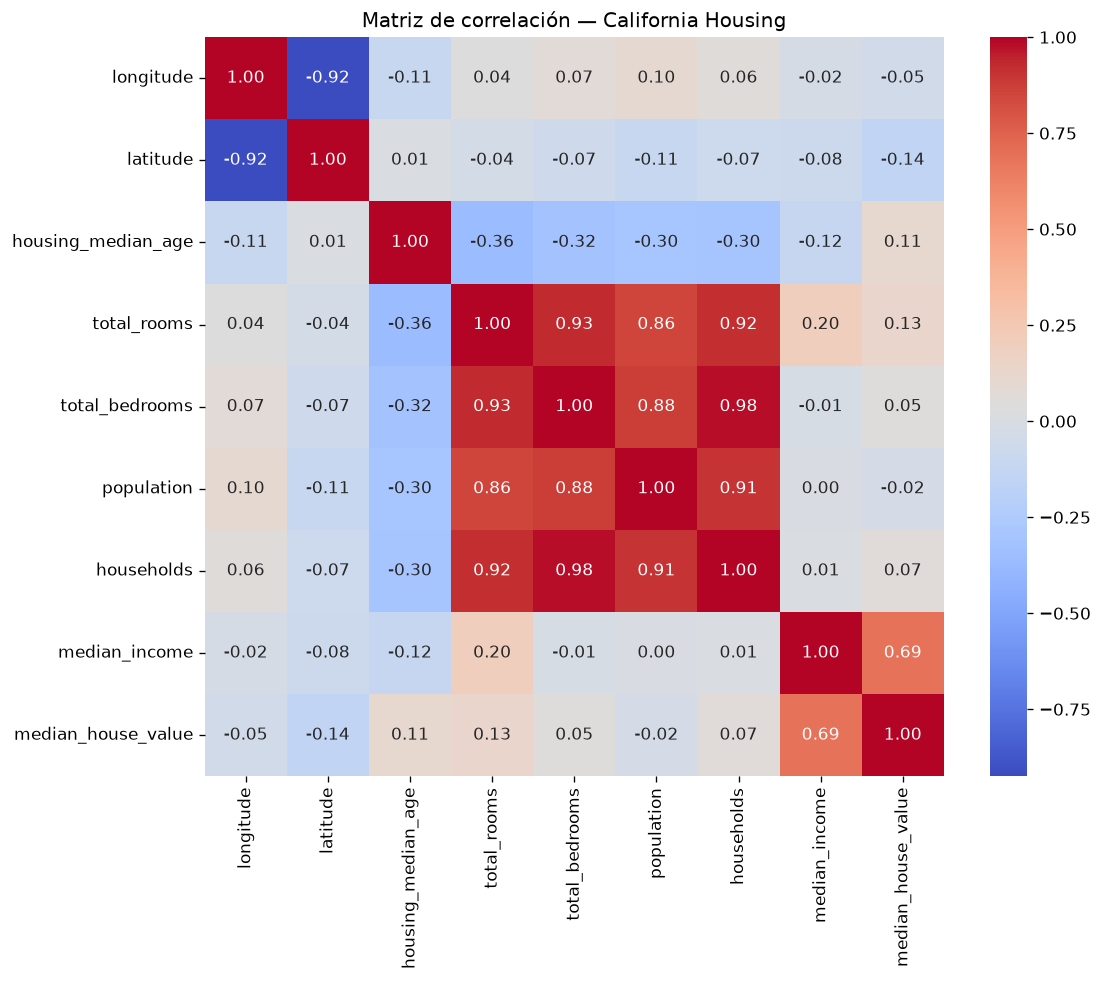

In [11]:
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de correlación — California Housing')
plt.show()

In [12]:
print('Correlación con la variable objetivo:')
print(corr[TARGET].sort_values(ascending=False).round(3).to_string())

Correlación con la variable objetivo:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144


## 11. Multicolinealidad (VIF)

El *Variance Inflation Factor* cuantifica cuánto se infla la varianza de un coeficiente por la correlación con las demás variables. Se calcula sobre las numéricas imputadas + One-Hot de `ocean_proximity` (sin la primera categoría).

Valores de VIF > 10 indican multicolinealidad severa: `total_bedrooms` (27) y `households` (28) la presentan, por lo que sus coeficientes individuales son poco interpretables aunque la predicción global sigue siendo válida. **No se eliminan variables**.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif_num = SimpleImputer(strategy='median').fit_transform(df[NUMERIC_FEATURES])
enc = OneHotEncoder(drop='first', sparse_output=False)
X_vif_cat = enc.fit_transform(df[CATEGORICAL_FEATURES])
X_vif = np.hstack([X_vif_num, X_vif_cat])
vif_names = NUMERIC_FEATURES + list(enc.get_feature_names_out(CATEGORICAL_FEATURES))

vif_table = []
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif, i)
    vif_table.append((vif_names[i], round(vif, 2)))
pd.DataFrame(vif_table, columns=['Variable', 'VIF'])

,Variable,VIF
0,longitude,838.18
1,latitude,813.60
2,housing_median_age,8.12
3,total_rooms,30.27
4,total_bedrooms,70.55
5,population,16.38
6,households,75.29
7,median_income,8.83
8,ocean_proximity_INLAND,2.72
9,ocean_proximity_ISLAND,1.00


## 12. Preprocesamiento

Se construye el `ColumnTransformer` que combina:
- **Numéricas**: `SimpleImputer(mediana)` + `StandardScaler`.
- **Categórica**: `OneHotEncoder` (drop first, handle_unknown='ignore').

Los transformadores se ajustan solo con el conjunto de entrenamiento para evitar data leakage.

In [14]:
preprocessor = build_preprocessor()
print('Preprocesador creado.')
preprocessor

Preprocesador creado.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 13. División Train/Test

80% entrenamiento / 20% prueba con `random_state=42`.

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')

Train: 16512 filas | Test: 4128 filas


## 14. Modelos y pipelines

Se crean y entrenan los tres pipelines: Regresión Lineal Múltiple y Regresión Polinomial de grados 2 y 3.

In [16]:
models = build_models(preprocessor)
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f'Entrenado: {name}')

Entrenado: linear_regression
Entrenado: polynomial_degree_2


Entrenado: polynomial_degree_3


## 15. Evaluación

Métricas en prueba: MAE, MSE, RMSE y R².

In [17]:
table = metrics_table(models, X_train, y_train, X_test, y_test)
table.round(2)

,Modelo,R2_train,RMSE_train,R2_test,RMSE_test,MAE_test,MSE_test
0,linear_regression,0.65,68433.94,0.63,70059.19,50670.49,4.908291e+09
1,polynomial_degree_2,0.72,61480.69,0.66,67134.24,46385.63,4.507006e+09
2,polynomial_degree_3,0.78,54105.31,0.29,96404.86,43248.11,9.293898e+09


## 16. Análisis de sobreajuste

Se comparan R² y RMSE de entrenamiento frente a prueba. Una gran brecha entre ambos indica sobreajuste: el modelo memoriza el entrenamiento pero no generaliza.

In [18]:
over = table[['Modelo', 'R2_train', 'R2_test', 'RMSE_train', 'RMSE_test']]
over.round(2)

,Modelo,R2_train,R2_test,RMSE_train,RMSE_test
0,linear_regression,0.65,0.63,68433.94,70059.19
1,polynomial_degree_2,0.72,0.66,61480.69,67134.24
2,polynomial_degree_3,0.78,0.29,54105.31,96404.86


## 17. Selección del mejor modelo

El **grado 2** presenta el mejor equilibrio: R² de prueba superior al lineal sin caer en el sobreajuste del grado 3.

In [19]:
best = table.loc[table['R2_test'].idxmax(), 'Modelo']
print('Mejor modelo (R² test):', best)
table.nlargest(1, 'R2_test').round(2)

Mejor modelo (R² test): polynomial_degree_2


,Modelo,R2_train,RMSE_train,R2_test,RMSE_test,MAE_test,MSE_test
1,polynomial_degree_2,0.72,61480.69,0.66,67134.24,46385.63,4.507006e+09


## 18. Predicción de ejemplo

Se carga el pipeline guardado y se predice con un distrito típico (medianas de cada variable).

In [20]:
import joblib
from cases.california_housing.config import MODELS_DIR

sample = pd.DataFrame([{
    'longitude': -118.49, 'latitude': 34.26, 'housing_median_age': 29.0,
    'total_rooms': 2127.0, 'total_bedrooms': 435.0, 'population': 1166.0,
    'households': 409.0, 'median_income': 3.535, 'ocean_proximity': '<1H OCEAN'
}])

for key in models:
    pipe = joblib.load(MODELS_DIR / f'{key}.pkl')
    print(f'{key:22s} -> $ {pipe.predict(sample)[0]:,.0f}')

linear_regression      -> $ 210,609


polynomial_degree_2    -> $ 213,220
polynomial_degree_3    -> $ 217,418


## 19. Conclusiones

- `median_income` es el predictor con mayor influencia (r = 0.688).
- La multicolinealidad entre conteos (rooms/bedrooms/population/households) dificulta interpretar coeficientes individuales, pero no impide predecir.
- La Regresión Polinomial de **grado 2** supera a la lineal (R² 0.66 vs 0.63); el **grado 3** sobreajusta (R² test cae a 0.29).
- El dataset contiene valores censurados en el tope de 500,001; se conservaron y documentaron.